## Data Collection
Data pulled from the EIA API: Henry Hub daily spot prices, weekly natural gas storage, monthly LNG exports, dry gas production, and total consumption. HDD data sourced from NOAA.

            Henry Hub
Date                 
1997-01-07       3.82
1997-01-08       3.80
1997-01-09       3.61
1997-01-10       3.92
1997-01-13       4.00
            Henry Hub
Date                 
2026-06-15       3.06
2026-06-16       3.10
2026-06-17       3.25
2026-06-18       3.08
2026-06-22       3.16
7402


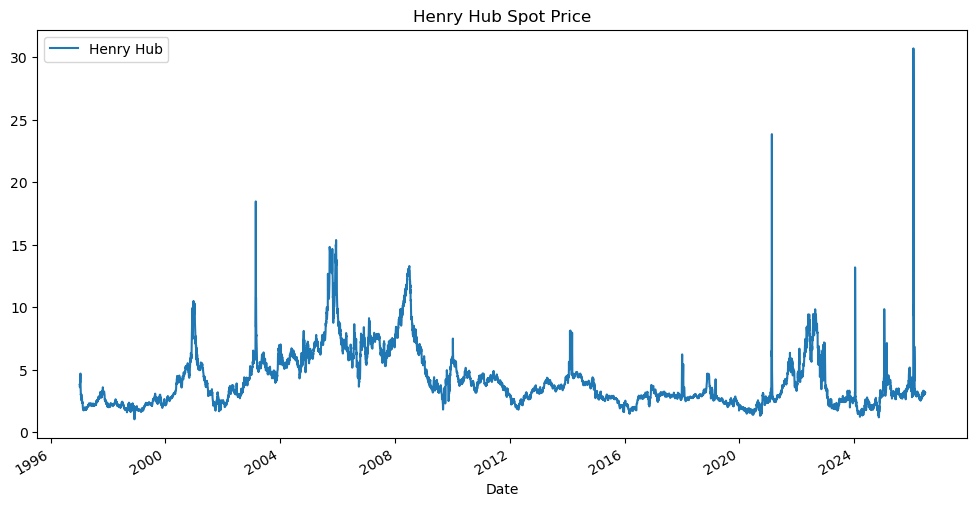

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

api_key = "YOUR-API-KEY"

base_url = "https://api.eia.gov/v2/natural-gas/pri/fut/data/"

params = {
    "api_key": api_key,
    "frequency": "daily",
    "data[0]": "value",
    "facets[series][]": "RNGWHHD",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0,
}

all_rows = []

while True:
    response = requests.get(base_url, params=params)
    data = response.json()

    if "response" not in data:
        print(data)
        break

    rows = data["response"]["data"]
    if not rows:
        break

    all_rows.extend(rows)

    if len(rows) < 5000:
        break

    params["offset"] += 5000

df = pd.DataFrame(all_rows)

df["period"] = pd.to_datetime(df["period"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")

df = (
    df.sort_values("period")[["period", "value"]]
      .rename(columns={"period": "Date", "value": "Henry Hub"})
      .set_index("Date")
)

print(df.head())
print(df.tail())
print(len(df))

df.plot(figsize=(12, 6), title="Henry Hub Spot Price")
plt.show()

In [3]:
storage_url = "https://api.eia.gov/v2/natural-gas/stor/wkly/data/"
params_storage = {
    "api_key": api_key,
    "frequency": "weekly",
    "data[0]": "value",
    "facets[series][]": "NW2_EPG0_SWO_R48_BCF",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0,
}
all_storage_rows = []
while True:
    response = requests.get(storage_url, params=params_storage)
    data = response.json()
    if "response" not in data:
        print(data)
        break
    rows = data["response"]["data"]
    if not rows:
        break
    all_storage_rows.extend(rows)
    if len(rows) < 5000:
        break
    params_storage["offset"] += 5000

storage_df = pd.DataFrame(all_storage_rows)
storage_df["period"] = pd.to_datetime(storage_df["period"])
storage_df["value"] = pd.to_numeric(storage_df["value"], errors="coerce")
storage_df = (
    storage_df.sort_values("period")[["period", "value"]]
    .rename(columns={"period": "Date", "value": "Storage_BCF"})
    .set_index("Date")
)

storage_df["week"] = storage_df.index.isocalendar().week.astype(int)
storage_df["year"] = storage_df.index.year

def rolling_5yr_avg(row, df):
    prior_5 = df[
        (df["year"] >= row["year"] - 5) &
        (df["year"] < row["year"]) &
        (df["week"] == row["week"])
    ]["Storage_BCF"]
    return prior_5.mean()

storage_df["avg_5yr"] = storage_df.apply(
    lambda row: rolling_5yr_avg(row, storage_df), axis=1
)
storage_df["surplus_deficit"] = storage_df["Storage_BCF"] - storage_df["avg_5yr"]

print(storage_df.tail(10))
print(f"\nTotal weeks: {len(storage_df)}")
print(storage_df[storage_df["year"] == 2015].head(10))

            Storage_BCF  week  year  avg_5yr  surplus_deficit
Date                                                         
2026-04-17         2063    16  2026   1951.2            111.8
2026-04-24         2142    17  2026   2022.6            119.4
2026-05-01         2205    18  2026   2105.4             99.6
2026-05-08         2290    19  2026   2193.4             96.6
2026-05-15         2391    20  2026   2292.8             98.2
2026-05-22         2483    21  2026   2388.0             95.0
2026-05-29         2578    22  2026   2492.4             85.6
2026-06-05         2686    23  2026   2567.4            118.6
2026-06-12         2759    24  2026   2645.4            113.6
2026-06-19         2835    25  2026   2722.8            112.2

Total weeks: 860
            Storage_BCF  week  year  avg_5yr  surplus_deficit
Date                                                         
2015-01-02         3089     1  2015   3064.0             25.0
2015-01-09         2854     2  2015   2861.8        

In [4]:
hdd_url = "https://api.eia.gov/v2/steo/data/"

params_hdd = {
    "api_key": api_key,
    "frequency": "monthly",
    "data[0]": "value",
    "facets[seriesId][]": "ZWHDPUS",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0,
}

all_hdd_rows = []
while True:
    response = requests.get(hdd_url, params=params_hdd)
    data = response.json()
    if "response" not in data:
        print(data)
        break
    rows = data["response"]["data"]
    if not rows:
        break
    all_hdd_rows.extend(rows)
    if len(rows) < 5000:
        break
    params_hdd["offset"] += 5000

hdd_df = pd.DataFrame(all_hdd_rows)
hdd_df["period"] = pd.to_datetime(hdd_df["period"])
hdd_df["value"] = pd.to_numeric(hdd_df["value"], errors="coerce")
hdd_df = (
    hdd_df.sort_values("period")[["period", "value"]]
    .rename(columns={"period": "Date", "value": "HDD"})
    .set_index("Date")
)

# Filter to historical only - remove future forecasts
hdd_df = hdd_df[hdd_df.index <= pd.Timestamp.today()]

print(hdd_df.head())
print(hdd_df.tail())
print(f"Total months: {len(hdd_df)}")

                   HDD
Date                  
1990-01-01  745.854576
1990-02-01  672.049282
1990-03-01  551.679168
1990-04-01  339.295874
1990-05-01  202.100910
                   HDD
Date                  
2026-02-01  652.783364
2026-03-01  401.854125
2026-04-01  238.843224
2026-05-01  142.919725
2026-06-01   27.990620
Total months: 438


In [5]:
lng_url = "https://api.eia.gov/v2/natural-gas/move/expc/data/"

params_lng = {
    "api_key": api_key,
    "frequency": "monthly",
    "data[0]": "value",
    "facets[series][]": "NGM_EPG0_EVT_NUS-Z00_MMCF",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0,
}

all_lng_rows = []
while True:
    response = requests.get(lng_url, params=params_lng)
    data = response.json()
    if "response" not in data:
        print(data)
        break
    rows = data["response"]["data"]
    if not rows:
        break
    all_lng_rows.extend(rows)
    if len(rows) < 5000:
        break
    params_lng["offset"] += 5000

lng_df = pd.DataFrame(all_lng_rows)
lng_df["period"] = pd.to_datetime(lng_df["period"])
lng_df["value"] = pd.to_numeric(lng_df["value"], errors="coerce")
lng_df = (
    lng_df.sort_values("period")[["period", "value"]]
    .rename(columns={"period": "Date", "value": "LNG_exports_MMcf"})
    .set_index("Date")
)

print(lng_df.head())
print(lng_df.tail())
print(f"Total months: {len(lng_df)}")

            LNG_exports_MMcf
Date                        
2014-01-01                29
2014-02-01                30
2014-03-01                28
2014-04-01                25
2014-05-01              1907
            LNG_exports_MMcf
Date                        
2025-11-01            525089
2025-12-01            569267
2026-01-01            539203
2026-02-01            493617
2026-03-01            573479
Total months: 147


In [6]:
prod_url = "https://api.eia.gov/v2/natural-gas/prod/sum/data/"
params_prod = {
    "api_key": api_key,
    "frequency": "monthly",
    "data[0]": "value",
    "facets[series][]": "N9070US2",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0,
}

all_prod_rows = []
while True:
    response = requests.get(prod_url, params=params_prod)
    data = response.json()
    if "response" not in data:
        print(data)
        break
    rows = data["response"]["data"]
    if not rows:
        break
    all_prod_rows.extend(rows)
    if len(rows) < 5000:
        break
    params_prod["offset"] += 5000

prod_df = pd.DataFrame(all_prod_rows)
prod_df["period"] = pd.to_datetime(prod_df["period"])
prod_df["value"] = pd.to_numeric(prod_df["value"], errors="coerce")
prod_df = (
    prod_df.sort_values("period")[["period", "value"]]
    .rename(columns={"period": "Date", "value": "NaturalGas_production_MMcf"})
    .set_index("Date")
)

print(prod_df.head())
print(prod_df.tail())
print(f"Total months: {len(prod_df)}")

            NaturalGas_production_MMcf
Date                                  
1997-01-01                     1617923
1997-02-01                     1465907
1997-03-01                     1627602
1997-04-01                     1551268
1997-05-01                     1610527
            NaturalGas_production_MMcf
Date                                  
2025-11-01                     3308316
2025-12-01                     3460493
2026-01-01                     3371529
2026-02-01                     3097332
2026-03-01                     3438485
Total months: 351


In [7]:
cons_url = "https://api.eia.gov/v2/natural-gas/cons/sum/data/"

params_cons = {
    "api_key": api_key,
    "frequency": "monthly",
    "data[0]": "value",
    "facets[duoarea][]": "NUS",
    "facets[process][]": "VGT",
    "facets[series][]": "N3060US2",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
    "offset": 0
} 

all_cons_rows = []
while True:
    response = requests.get(cons_url, params=params_cons)
    data = response.json()
    if "response" not in data:
        print(data)
        break
    rows = data["response"]["data"]
    if not rows:
        break
    all_cons_rows.extend(rows)
    if len(rows) < 5000:
        break
    params_cons["offset"] += 5000

cons_df = pd.DataFrame(all_cons_rows)
cons_df["period"] = pd.to_datetime(cons_df["period"])
cons_df["value"] = pd.to_numeric(cons_df["value"], errors="coerce")
cons_df = (
    cons_df.sort_values("period")[["period", "value"]]
    .rename(columns={"period": "Date", "value": "NaturalGas_consumption_MMcf"})
    .set_index("Date")
)

print(cons_df.head())
print(cons_df.tail())
print(f"Total months: {len(cons_df)}")

            NaturalGas_consumption_MMcf
Date                                   
2001-01-01                      2505011
2001-02-01                      2156873
2001-03-01                      2086568
2001-04-01                      1663832
2001-05-01                      1385163
            NaturalGas_consumption_MMcf
Date                                   
2025-11-01                      2502941
2025-12-01                      3183876
2026-01-01                      3465907
2026-02-01                      2835071
2026-03-01                      2493289
Total months: 303


## Data Preparation & Feature Engineering
Raw series are merged into a single monthly dataframe. Engineered features include: percent change in Henry Hub price, storage surplus/deficit vs. 5-year average, and a one-month lagged price variable.

In [8]:
# Resample Henry Hub to monthly average
hh_monthly = df["Henry Hub"].resample("MS").mean()

# Resample storage surplus/deficit to monthly average
# We only need the surplus/deficit column, not week/year/avg_5yr
storage_monthly = storage_df["surplus_deficit"].resample("MS").mean()

# HDD is already monthly
hdd_monthly = hdd_df["HDD"]

# LNG, production, consumption are already monthly
lng_monthly = lng_df["LNG_exports_MMcf"]
prod_monthly = prod_df["NaturalGas_production_MMcf"]
cons_monthly = cons_df["NaturalGas_consumption_MMcf"]

# Merge everything into one DataFrame
combined = pd.concat([
    hh_monthly,
    storage_monthly,
    hdd_monthly,
    lng_monthly,
    prod_monthly,
    cons_monthly
], axis=1)

combined.columns = [
    "HH_price",
    "storage_surplus",
    "HDD",
    "LNG_exports",
    "production",
    "consumption"
]

print(combined.shape)
print(combined.head())
print(combined.tail())
print("\nMissing values per column:")
print(combined.isnull().sum())

(438, 6)
            HH_price  storage_surplus         HDD  LNG_exports  production  \
Date                                                                         
1990-01-01       NaN              NaN  745.854576          NaN         NaN   
1990-02-01       NaN              NaN  672.049282          NaN         NaN   
1990-03-01       NaN              NaN  551.679168          NaN         NaN   
1990-04-01       NaN              NaN  339.295874          NaN         NaN   
1990-05-01       NaN              NaN  202.100910          NaN         NaN   

            consumption  
Date                     
1990-01-01          NaN  
1990-02-01          NaN  
1990-03-01          NaN  
1990-04-01          NaN  
1990-05-01          NaN  
            HH_price  storage_surplus         HDD  LNG_exports  production  \
Date                                                                         
2026-02-01  3.621579            -15.4  652.783364     493617.0   3097332.0   
2026-03-01  3.044091        

In [9]:
# Regression dataset - only rows where all variables are present
# This will naturally restrict to the overlapping period
regression_df = combined.dropna()

print(f"Full dataset: {combined.shape[0]} months")
print(f"Regression dataset: {regression_df.shape[0]} months")
print(f"Regression period: {regression_df.index.min().date()} to {regression_df.index.max().date()}")

Full dataset: 438 months
Regression dataset: 147 months
Regression period: 2014-01-01 to 2026-03-01


In [10]:
# Create percent change variables for regression
reg = regression_df.copy()

# Percent change in price - this is our dependent variable
reg["pct_change_price"] = reg["HH_price"].pct_change() * 100

# Changes in fundamentals - these are our independent variables
reg["change_storage_surplus"] = reg["storage_surplus"].diff()
reg["change_HDD"] = reg["HDD"].diff()
reg["pct_change_LNG"] = reg["LNG_exports"].pct_change() * 100
reg["pct_change_production"] = reg["production"].pct_change() * 100
reg["pct_change_consumption"] = reg["consumption"].pct_change() * 100

# Drop the first row which will be NaN after differencing
reg = reg.dropna()

print(reg.shape)
print(reg[["pct_change_price", "change_storage_surplus", 
           "change_HDD", "pct_change_LNG",
           "pct_change_production", "pct_change_consumption"]].describe().round(3))

(146, 12)
       pct_change_price  change_storage_surplus  change_HDD  pct_change_LNG  \
count           146.000                 146.000     146.000         146.000   
mean              1.440                   3.044      -3.902         305.890   
std              19.146                 106.864     177.536        1869.937   
min             -53.076                -320.240    -358.815         -99.242   
25%              -7.823                 -52.560    -139.703          -4.488   
50%              -0.436                  -1.585     -12.867           1.398   
75%               8.704                  70.950     134.065          12.170   
max              97.361                 326.600     394.143       16529.412   

       pct_change_production  pct_change_consumption  
count                146.000                 146.000  
mean                   0.484                   0.724  
std                    5.266                  13.154  
min                  -16.369                 -25.610  
25%

## Regression Analysis
OLS regression models estimating the relationship between Henry Hub monthly price changes and fundamental drivers: storage surplus, dry gas production, total consumption, and lagged price. Models 1–5 test variable combinations; Model 7 adds the lagged price term.

In [11]:
# Define dependent and independent variables
y = reg["pct_change_price"]

X = reg[[
    "change_storage_surplus",
    "change_HDD",
    "pct_change_LNG",
    "pct_change_production",
    "pct_change_consumption"
]]

# Add constant for intercept
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     7.753
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.83e-06
Time:                        10:52:36   Log-Likelihood:                -619.83
No. Observations:                 146   AIC:                             1252.
Df Residuals:                     140   BIC:                             1270.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [12]:
# Log transform LNG exports
reg["log_LNG"] = np.log(reg["LNG_exports"])
reg["change_log_LNG"] = reg["log_LNG"].diff()

# Drop the one NaN created by diff
reg_clean = reg.dropna(subset=["change_log_LNG"])

# Define new cleaner model
y2 = reg_clean["pct_change_price"]

X2 = reg_clean[[
    "change_storage_surplus",
    "pct_change_production",
    "change_log_LNG"
]]

X2 = sm.add_constant(X2)

model2 = sm.OLS(y2, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     7.506
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           0.000107
Time:                        10:52:36   Log-Likelihood:                -622.13
No. Observations:                 145   AIC:                             1252.
Df Residuals:                     141   BIC:                             1264.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [13]:
y3 = reg["pct_change_price"]

X3 = reg[[
    "change_storage_surplus",
    "pct_change_production",
]]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y3, X3).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     12.45
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.04e-05
Time:                        10:52:37   Log-Likelihood:                -625.95
No. Observations:                 146   AIC:                             1258.
Df Residuals:                     143   BIC:                             1267.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [14]:
y4 = reg["pct_change_price"]

X4 = reg[[
    "change_storage_surplus",
    "pct_change_production",
    "change_HDD"
]]

X4 = sm.add_constant(X4)

model4 = sm.OLS(y4, X4).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     11.99
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.84e-07
Time:                        10:52:38   Log-Likelihood:                -621.19
No. Observations:                 146   AIC:                             1250.
Df Residuals:                     142   BIC:                             1262.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

In [15]:
y5 = reg["pct_change_price"]

X5 = reg[[
    "change_storage_surplus",
    "pct_change_production",
    "pct_change_consumption"
]]

X5 = sm.add_constant(X5)
model5 = sm.OLS(y5, X5).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     12.98
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.54e-07
Time:                        10:52:39   Log-Likelihood:                -619.98
No. Observations:                 146   AIC:                             1248.
Df Residuals:                     142   BIC:                             1260.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [16]:
# Model 7 - adds lagged price change to model 5
# Create completely independent copy to avoid contaminating other models
# Note: Model 6 tested HDD + consumption simultaneously
# and was dropped — both variables became insignificant
# due to collinearity, confirming consumption alone is
# the better demand proxy


reg7 = regression_df.copy()

reg7["pct_change_price"] = reg7["HH_price"].pct_change() * 100
reg7["change_storage_surplus"] = reg7["storage_surplus"].diff()
reg7["pct_change_production"] = reg7["production"].pct_change() * 100
reg7["pct_change_consumption"] = reg7["consumption"].pct_change() * 100
reg7["price_change_lag1"] = reg7["HH_price"].pct_change().shift(1) * 100

reg7 = reg7.dropna()

y7 = reg7["pct_change_price"]

X7 = reg7[[
    "change_storage_surplus",
    "pct_change_production",
    "pct_change_consumption",
    "price_change_lag1"
]]

X7 = sm.add_constant(X7)
model7 = sm.OLS(y7, X7).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:       pct_change_price   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     11.77
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.85e-08
Time:                        10:52:39   Log-Likelihood:                -611.85
No. Observations:                 145   AIC:                             1234.
Df Residuals:                     140   BIC:                             1249.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

## Visualizations

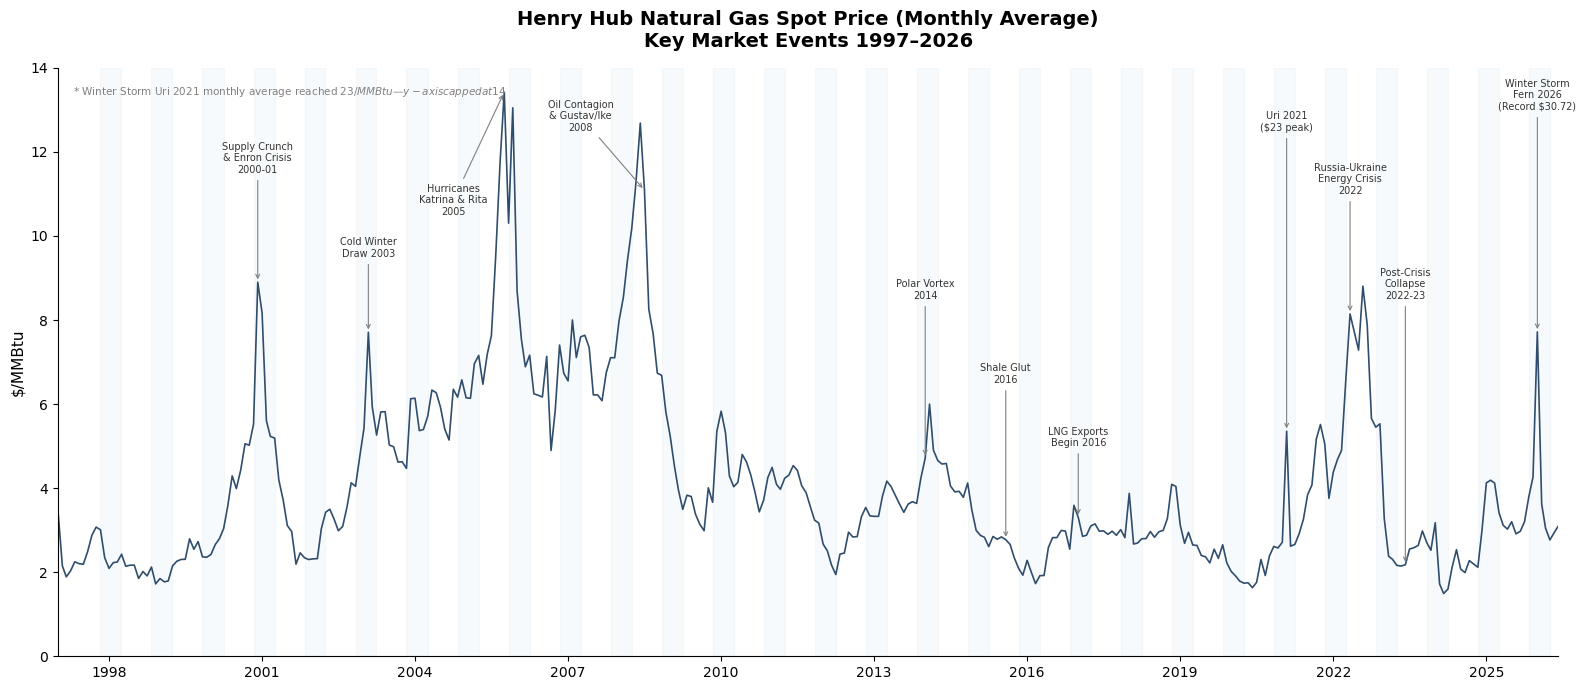

In [17]:
fig, ax = plt.subplots(figsize=(16, 7))

plot_data = combined[combined.index <= pd.Timestamp.today()]

ax.plot(plot_data.index, plot_data["HH_price"],
        color="#1a3a5c", linewidth=1.2, alpha=0.9)

for year in range(1997, 2027):
    ax.axvspan(pd.Timestamp(f"{year}-11-01"),
               pd.Timestamp(f"{year+1}-03-31"),
               color="steelblue", alpha=0.04)

ax.set_ylim(0, 14)
ax.set_xlim(pd.Timestamp("1997-01-01"), pd.Timestamp("2026-06-01"))

events = {
    "Supply Crunch\n& Enron Crisis\n2000-01":  ("2000-12-01", 11.5),
    "Cold Winter\nDraw 2003":                  ("2003-02-01", 9.5),
    "Hurricanes\nKatrina & Rita\n2005":        ("2004-10-01", 10.5),
    "Oil Contagion\n& Gustav/Ike\n2008":       ("2007-04-01", 12.5),
    "Polar Vortex\n2014":                      ("2014-01-01", 8.5),
    "Shale Glut\n2016":                        ("2015-08-01", 6.5),
    "LNG Exports\nBegin 2016":                 ("2017-01-01", 5.0),
    "Uri 2021\n($23 peak)":                    ("2021-02-01", 12.5),
    "Russia-Ukraine\nEnergy Crisis\n2022":     ("2022-05-01", 11.0),
    "Post-Crisis\nCollapse\n2022-23":          ("2023-06-01", 8.5),
    "Winter Storm\nFern 2026\n(Record $30.72)": ("2026-01-01", 13.0),
}

for label, (date, y_text) in events.items():
    ts = pd.Timestamp(date)
    
    # For Katrina/Rita, point arrow to actual spike date
    if "Katrina" in label:
        target_ts = pd.Timestamp("2005-10-01")
    elif "Gustav" in label:
        target_ts = pd.Timestamp("2008-07-01")
    else:
        target_ts = ts
    
    closest = plot_data["HH_price"].dropna().index[
        plot_data["HH_price"].dropna().index.get_indexer(
            [target_ts], method="nearest")[0]
    ]
    actual_price = min(plot_data.loc[closest, "HH_price"], 13.5)

    ax.annotate(label,
                xy=(closest, actual_price),
                xytext=(pd.Timestamp(date), y_text),
                fontsize=7,
                color="#333333",
                ha="center",
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_title("Henry Hub Natural Gas Spot Price (Monthly Average)\nKey Market Events 1997–2026",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("$/MMBtu", fontsize=11)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.01, 0.97,
        "* Winter Storm Uri 2021 monthly average reached $23/MMBtu — y-axis capped at $14",
        transform=ax.transAxes, fontsize=7.5, color="gray", va="top")

plt.tight_layout()
plt.savefig("henry_hub_history.png", dpi=150, bbox_inches="tight")
plt.show()

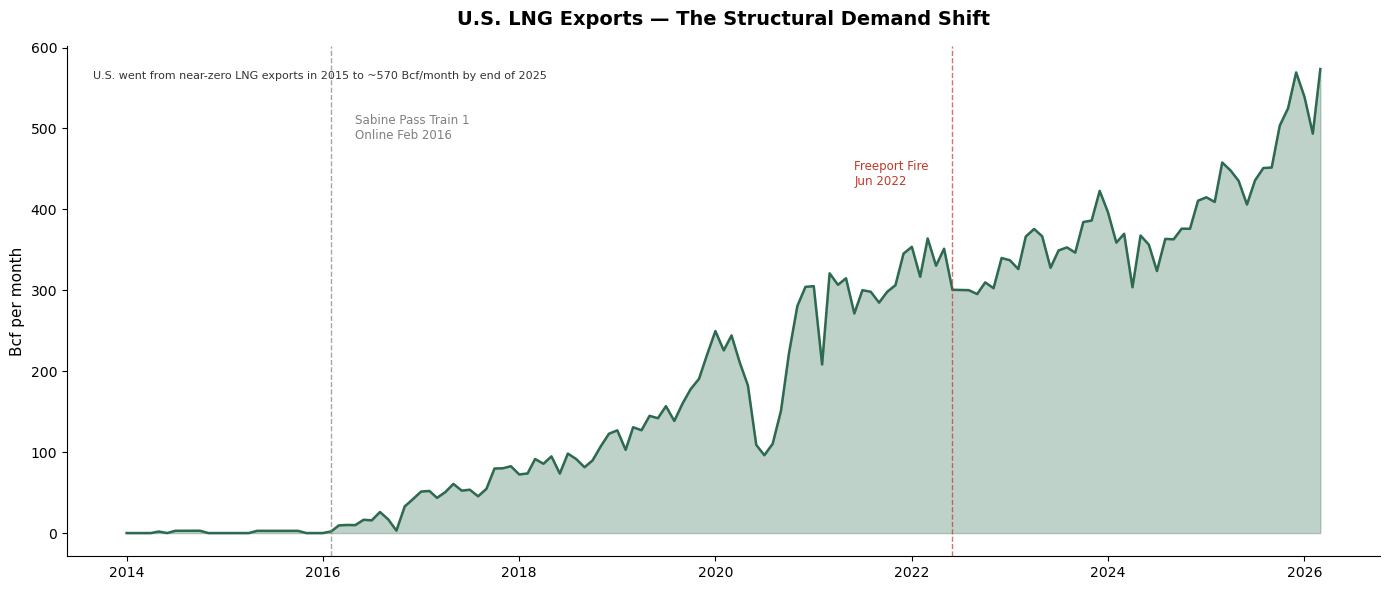

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

lng_plot = combined["LNG_exports"].dropna() / 1000  # Convert MMcf to Bcf

ax.fill_between(lng_plot.index, lng_plot,
                color="#2d6a4f", alpha=0.3)
ax.plot(lng_plot.index, lng_plot,
        color="#2d6a4f", linewidth=1.8)

ax.axvline(pd.Timestamp("2016-02-01"),
           color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.text(pd.Timestamp("2016-05-01"),
        lng_plot.max() * 0.85,
        "Sabine Pass Train 1\nOnline Feb 2016",
        fontsize=8.5, color="gray")

ax.axvline(pd.Timestamp("2022-06-01"),
           color="#c0392b", linestyle="--", linewidth=1, alpha=0.7)
ax.text(pd.Timestamp("2021-06-01"),
        lng_plot.max() * 0.75,
        "Freeport Fire\nJun 2022",
        fontsize=8.5, color="#c0392b")

ax.set_title("U.S. LNG Exports — The Structural Demand Shift",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Bcf per month", fontsize=11)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add context annotation
ax.text(0.02, 0.95,
        "U.S. went from near-zero LNG exports in 2015 to ~570 Bcf/month by end of 2025",
        transform=ax.transAxes, fontsize=8, color="#333333", va="top")

plt.tight_layout()
plt.savefig("lng_exports.png", dpi=150, bbox_inches="tight")
plt.show()

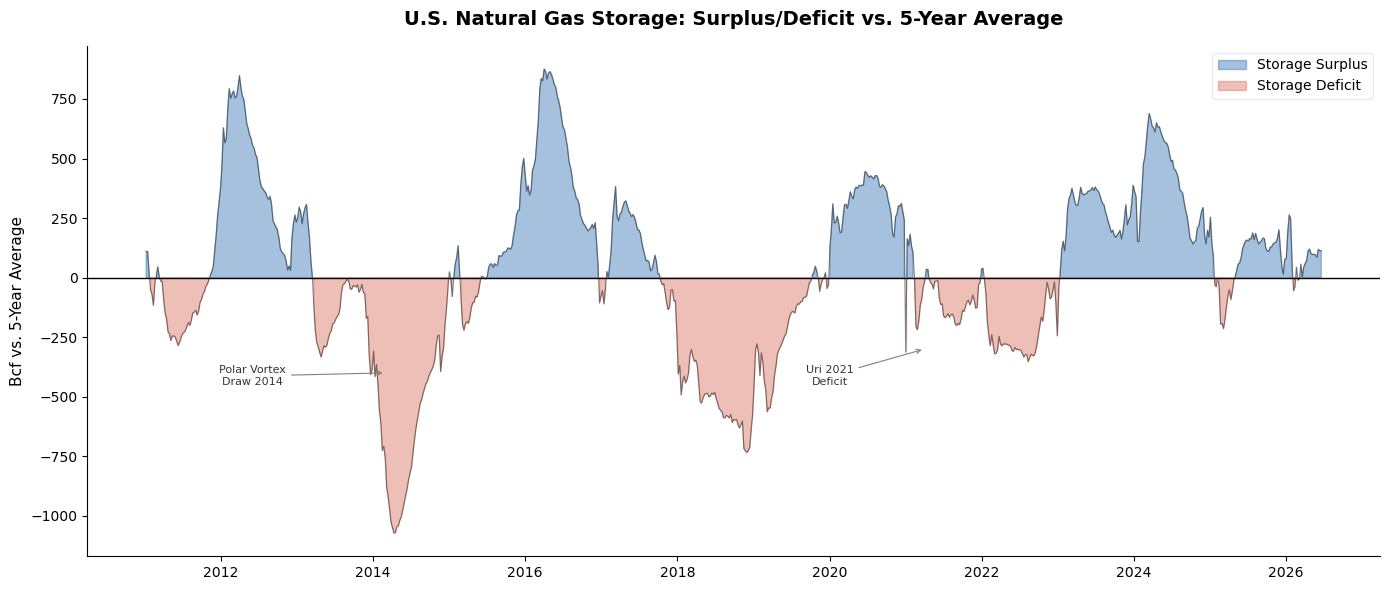

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

storage_plot = storage_df["surplus_deficit"].dropna()

ax.fill_between(storage_plot.index, storage_plot, 0,
                where=(storage_plot >= 0),
                color="#2166ac", alpha=0.4, label="Storage Surplus")
ax.fill_between(storage_plot.index, storage_plot, 0,
                where=(storage_plot < 0),
                color="#d6604d", alpha=0.4, label="Storage Deficit")
ax.plot(storage_plot.index, storage_plot,
        color="#333333", linewidth=0.8, alpha=0.6)
ax.axhline(0, color="black", linewidth=1)

# Annotate key deficit periods
ax.annotate("Polar Vortex\nDraw 2014",
            xy=(pd.Timestamp("2014-03-01"), -400),
            xytext=(pd.Timestamp("2012-06-01"), -450),
            fontsize=8, color="#333333", ha="center",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.annotate("Uri 2021\nDeficit",
            xy=(pd.Timestamp("2021-04-01"), -300),
            xytext=(pd.Timestamp("2020-01-01"), -450),
            fontsize=8, color="#333333", ha="center",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_title("U.S. Natural Gas Storage: Surplus/Deficit vs. 5-Year Average",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Bcf vs. 5-Year Average", fontsize=11)
ax.set_xlabel("")
ax.legend(fontsize=10, framealpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("storage_surplus.png", dpi=150, bbox_inches="tight")
plt.show()

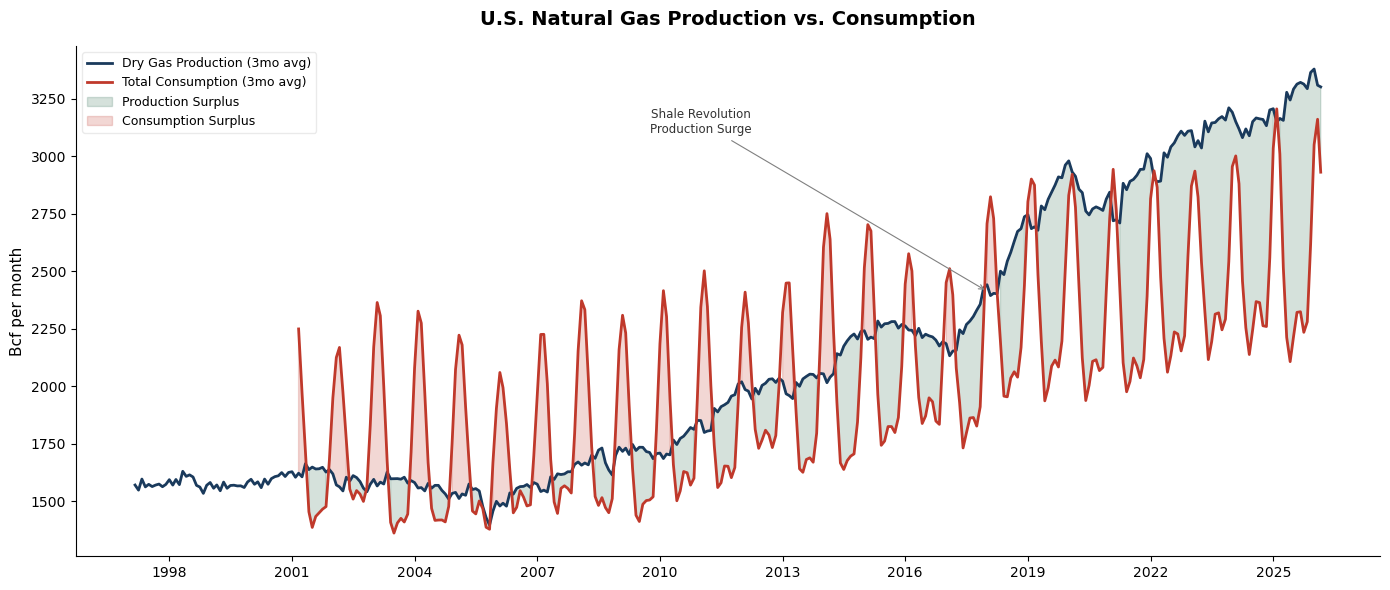

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

prod_plot = combined["production"].dropna().rolling(3).mean() / 1000
cons_plot = combined["consumption"].dropna().rolling(3).mean() / 1000

ax.plot(prod_plot.index, prod_plot,
        color="#1a3a5c", linewidth=2, label="Dry Gas Production (3mo avg)")
ax.plot(cons_plot.index, cons_plot,
        color="#c0392b", linewidth=2, label="Total Consumption (3mo avg)")

combined_plot = pd.DataFrame({"prod": prod_plot, "cons": cons_plot}).dropna()
ax.fill_between(combined_plot.index,
                combined_plot["prod"], combined_plot["cons"],
                where=(combined_plot["prod"] >= combined_plot["cons"]),
                color="#2d6a4f", alpha=0.2, label="Production Surplus")
ax.fill_between(combined_plot.index,
                combined_plot["prod"], combined_plot["cons"],
                where=(combined_plot["prod"] < combined_plot["cons"]),
                color="#c0392b", alpha=0.2, label="Consumption Surplus")

ax.annotate("Shale Revolution\nProduction Surge",
            xy=(pd.Timestamp("2018-01-01"),
                prod_plot.loc["2018-01-01":"2018-03-01"].mean()),
            xytext=(pd.Timestamp("2011-01-01"), 3100),
            fontsize=8.5, color="#333333", ha="center",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_title("U.S. Natural Gas Production vs. Consumption",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Bcf per month", fontsize=11)
ax.set_xlabel("")
ax.legend(fontsize=9, framealpha=0.4, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("production_consumption.png", dpi=150, bbox_inches="tight")
plt.show()

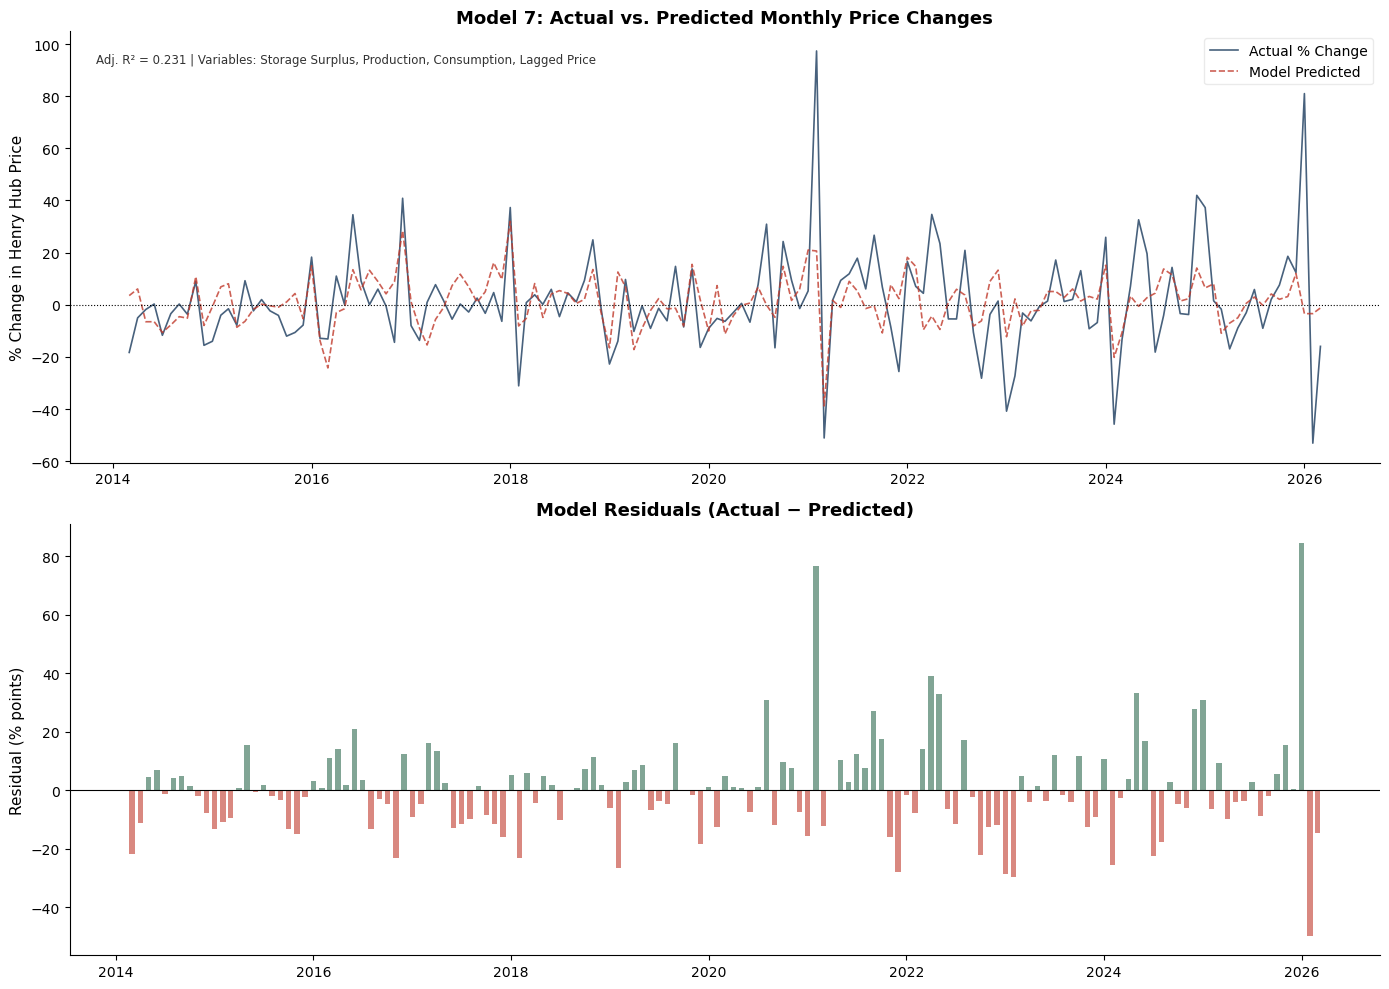

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top panel: Actual vs Predicted price changes ---
predicted = model7.fittedvalues
actual = y7
axes[0].plot(actual.index, actual.values,
             color="#1a3a5c", linewidth=1.2, label="Actual % Change", alpha=0.8)
axes[0].plot(predicted.index, predicted.values,
             color="#c0392b", linewidth=1.2, label="Model Predicted", alpha=0.8,
             linestyle="--")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_title("Model 7: Actual vs. Predicted Monthly Price Changes",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("% Change in Henry Hub Price", fontsize=11)
axes[0].legend(fontsize=10, framealpha=0.4)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# --- Bottom panel: Residuals ---
residuals = model7.resid
axes[1].bar(residuals.index, residuals.values,
            color=["#c0392b" if r < 0 else "#2d6a4f" for r in residuals.values],
            alpha=0.6, width=20)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Model Residuals (Actual − Predicted)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Residual (% points)", fontsize=11)
axes[1].set_xlabel("")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Add R-squared annotation
axes[0].text(0.02, 0.95,
             f"Adj. R² = 0.231 | Variables: Storage Surplus, Production, Consumption, Lagged Price",
             transform=axes[0].transAxes, fontsize=8.5,
             color="#333333", va="top")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches="tight")
plt.show()

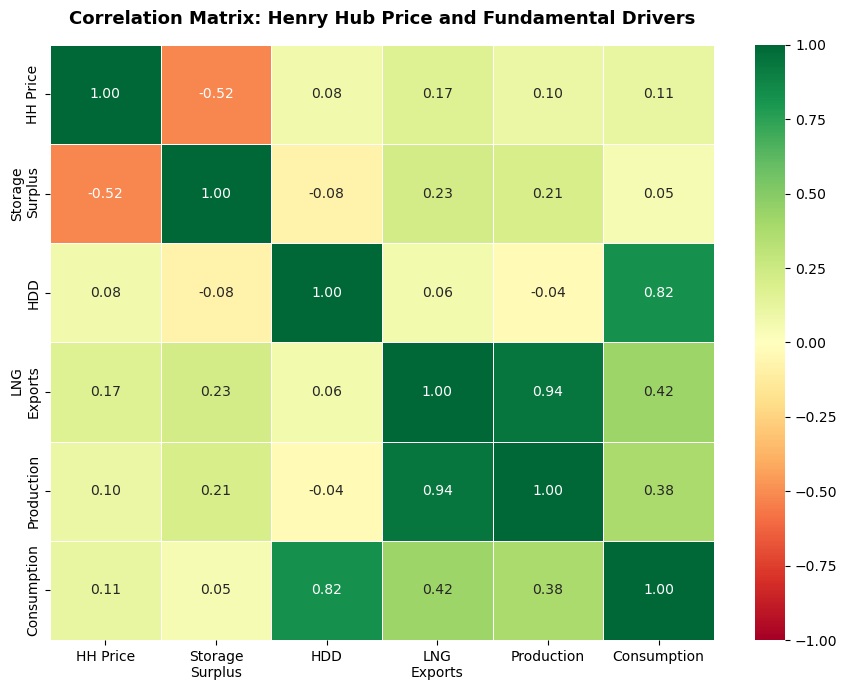

In [22]:
# Build correlation matrix from regression dataset
corr_cols = ["HH_price", "storage_surplus", "HDD", 
             "LNG_exports", "production", "consumption"]

corr_data = combined[corr_cols].dropna()

# Rename for cleaner labels
corr_data.columns = ["HH Price", "Storage\nSurplus", "HDD", 
                     "LNG\nExports", "Production", "Consumption"]

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5,
            annot_kws={"size": 10})

ax.set_title("Correlation Matrix: Henry Hub Price and Fundamental Drivers",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Creating Export File for PowerBI Dashboard

In [23]:
# Export combined dataset for Power BI
export_df = combined[combined.index <= pd.Timestamp.today()].copy()

# Convert units to Bcf for consistency
export_df["LNG_exports_Bcf"] = export_df["LNG_exports"] / 1000
export_df["production_Bcf"] = export_df["production"] / 1000
export_df["consumption_Bcf"] = export_df["consumption"] / 1000

# Drop original MMcf columns
export_df = export_df.drop(columns=["LNG_exports", "production", "consumption"])

# Round for cleanliness
export_df = export_df.round(3)

# Save
export_df.to_csv("natgas_fundamentals.csv")
print(f"Exported {len(export_df)} rows")
print(export_df.columns.tolist())
print(export_df.tail())

Exported 438 rows
['HH_price', 'storage_surplus', 'HDD', 'LNG_exports_Bcf', 'production_Bcf', 'consumption_Bcf']
            HH_price  storage_surplus      HDD  LNG_exports_Bcf  \
Date                                                              
2026-02-01     3.622            -15.4  652.783          493.617   
2026-03-01     3.044             25.0  401.854          573.479   
2026-04-01     2.768             90.2  238.843              NaN   
2026-05-01     2.939             95.0  142.920              NaN   
2026-06-01     3.104            114.8   27.991              NaN   

            production_Bcf  consumption_Bcf  
Date                                         
2026-02-01        3097.332         2835.071  
2026-03-01        3438.485         2493.289  
2026-04-01             NaN              NaN  
2026-05-01             NaN              NaN  
2026-06-01             NaN              NaN  


In [24]:
# Ensure all numeric columns are float type
numeric_cols = ["HH_price", "storage_surplus", "HDD", 
                "LNG_exports_Bcf", "production_Bcf", "consumption_Bcf"]

for col in numeric_cols:
    export_df[col] = pd.to_numeric(export_df[col], errors="coerce")

export_df.to_csv("natgas_fundamentals.csv")

In [25]:
# Read the CSV back and check dtypes
test = pd.read_csv("natgas_fundamentals.csv", index_col=0)
print(test.dtypes)
print(test.head(10))

HH_price           float64
storage_surplus    float64
HDD                float64
LNG_exports_Bcf    float64
production_Bcf     float64
consumption_Bcf    float64
dtype: object
            HH_price  storage_surplus      HDD  LNG_exports_Bcf  \
Date                                                              
1990-01-01       NaN              NaN  745.855              NaN   
1990-02-01       NaN              NaN  672.049              NaN   
1990-03-01       NaN              NaN  551.679              NaN   
1990-04-01       NaN              NaN  339.296              NaN   
1990-05-01       NaN              NaN  202.101              NaN   
1990-06-01       NaN              NaN   33.176              NaN   
1990-07-01       NaN              NaN    7.416              NaN   
1990-08-01       NaN              NaN   12.500              NaN   
1990-09-01       NaN              NaN   63.214              NaN   
1990-10-01       NaN              NaN  259.806              NaN   

            product

## Value at Risk (VaR) Analysis

VaR estimates the potential loss on a position over a given time period at a given confidence level. 
VaR is calculated using three methods and compare results:

- **Historical VaR**: Uses the actual empirical distribution of past returns
- **Parametric VaR**: Assumes normally distributed returns
- **Monte Carlo VaR**: Simulates thousands of future price paths

Monthly Henry Hub percent price changes are used as the return series and VaR is calculated at both 95% and 99% confidence levels.

A key finding from the regression diagnostics — high kurtosis (9.1) and positive skew (0.95) — means the normal distribution assumption in Parametric VaR will likely **underestimate tail risk**. The comparison across methods will demonstrate this directly.

In [26]:
# ============================================================
# VALUE AT RISK (VaR) ANALYSIS
# Henry Hub Natural Gas - Monthly Price Returns
# ============================================================

# We use monthly percent changes in Henry Hub price
# as our return series - already calculated in reg
returns = reg["pct_change_price"].dropna()

print(f"Return series: {len(returns)} monthly observations")
print(f"Period: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"\nReturn statistics:")
print(f"Mean:     {returns.mean():.3f}%")
print(f"Std Dev:  {returns.std():.3f}%")
print(f"Min:      {returns.min():.3f}%")
print(f"Max:      {returns.max():.3f}%")
print(f"Skewness: {returns.skew():.3f}")
print(f"Kurtosis: {returns.kurtosis():.3f}")

Return series: 146 monthly observations
Period: 2014-02-01 to 2026-03-01

Return statistics:
Mean:     1.440%
Std Dev:  19.146%
Min:      -53.076%
Max:      97.361%
Skewness: 1.167
Kurtosis: 6.007


In [27]:
from scipy import stats

# Confidence levels
confidence_levels = [0.95, 0.99]

# ── METHOD 1: HISTORICAL VAR ──────────────────────────────
print("=" * 55)
print("METHOD 1: HISTORICAL VaR")
print("=" * 55)
print("Uses actual empirical distribution of past returns.")
print("No distributional assumptions required.\n")

for cl in confidence_levels:
    var_hist = np.percentile(returns, (1 - cl) * 100)
    print(f"  {int(cl*100)}% Historical VaR: {var_hist:.2f}%")

# ── METHOD 2: PARAMETRIC VAR ──────────────────────────────
print("\n" + "=" * 55)
print("METHOD 2: PARAMETRIC VaR (Normal Distribution)")
print("=" * 55)
print("Assumes returns are normally distributed.")
print("Will UNDERESTIMATE tail risk given kurtosis = 6.0\n")

mu = returns.mean()
sigma = returns.std()

for cl in confidence_levels:
    z_score = stats.norm.ppf(1 - cl)
    var_param = mu + z_score * sigma
    print(f"  {int(cl*100)}% Parametric VaR: {var_param:.2f}%")

# ── METHOD 3: MONTE CARLO VAR ─────────────────────────────
print("\n" + "=" * 55)
print("METHOD 3: MONTE CARLO VaR")
print("=" * 55)
print("Simulates 100,000 possible monthly returns")
print("using observed mean and volatility.\n")

np.random.seed(42)
n_simulations = 100_000
simulated_returns = np.random.normal(mu, sigma, n_simulations)

for cl in confidence_levels:
    var_mc = np.percentile(simulated_returns, (1 - cl) * 100)
    print(f"  {int(cl*100)}% Monte Carlo VaR: {var_mc:.2f}%")

# ── COMPARISON TABLE ──────────────────────────────────────
print("\n" + "=" * 55)
print("COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Method':<25} {'95% VaR':>10} {'99% VaR':>10}")
print("-" * 45)

for cl in confidence_levels:
    hist = np.percentile(returns, (1 - cl) * 100)
    param = mu + stats.norm.ppf(1 - cl) * sigma
    mc = np.percentile(np.random.normal(mu, sigma, n_simulations), 
                       (1 - cl) * 100)
    
    if cl == 0.95:
        r95_h, r95_p, r95_m = hist, param, mc
    else:
        r99_h, r99_p, r99_m = hist, param, mc

print(f"{'Historical':<25} {r95_h:>9.2f}% {r99_h:>9.2f}%")
print(f"{'Parametric (Normal)':<25} {r95_p:>9.2f}% {r99_p:>9.2f}%")
print(f"{'Monte Carlo':<25} {r95_m:>9.2f}% {r99_m:>9.2f}%")

print(f"\nNote: Positive VaR values mean losses in that percentile.")
print(f"A 95% Historical VaR of X% means there is a 5% chance")
print(f"of losing more than X% in a given month.")

METHOD 1: HISTORICAL VaR
Uses actual empirical distribution of past returns.
No distributional assumptions required.

  95% Historical VaR: -24.88%
  99% Historical VaR: -48.71%

METHOD 2: PARAMETRIC VaR (Normal Distribution)
Assumes returns are normally distributed.
Will UNDERESTIMATE tail risk given kurtosis = 6.0

  95% Parametric VaR: -30.05%
  99% Parametric VaR: -43.10%

METHOD 3: MONTE CARLO VaR
Simulates 100,000 possible monthly returns
using observed mean and volatility.

  95% Monte Carlo VaR: -30.03%
  99% Monte Carlo VaR: -43.26%

COMPARISON SUMMARY
Method                       95% VaR    99% VaR
---------------------------------------------
Historical                   -24.88%    -48.71%
Parametric (Normal)          -30.05%    -43.10%
Monte Carlo                  -29.96%    -43.30%

Note: Positive VaR values mean losses in that percentile.
A 95% Historical VaR of X% means there is a 5% chance
of losing more than X% in a given month.


In [28]:
# Fit a t-distribution to actual returns
df_t, loc_t, scale_t = stats.t.fit(returns)

print(f"Fitted t-distribution parameters:")
print(f"  Degrees of freedom: {df_t:.2f}")
print(f"  Location (mean):    {loc_t:.3f}%")
print(f"  Scale (spread):     {scale_t:.3f}%")
print(f"\n  Note: Lower df = fatter tails")
print(f"  Normal distribution = df of infinity")
print(f"  df of {df_t:.1f} reflects the fat tails")
print(f"  observed in natural gas returns\n")

# Monte Carlo using fitted t-distribution
np.random.seed(42)
simulated_t = stats.t.rvs(df=df_t, loc=loc_t, 
                           scale=scale_t, size=100_000)

for cl in confidence_levels:
    var_mc_t = np.percentile(simulated_t, (1 - cl) * 100)
    print(f"  {int(cl*100)}% Monte Carlo VaR (t-dist): {var_mc_t:.2f}%")

Fitted t-distribution parameters:
  Degrees of freedom: 2.20
  Location (mean):    -0.570%
  Scale (spread):     10.075%

  Note: Lower df = fatter tails
  Normal distribution = df of infinity
  df of 2.2 reflects the fat tails
  observed in natural gas returns

  95% Monte Carlo VaR (t-dist): -28.38%
  99% Monte Carlo VaR (t-dist): -62.86%


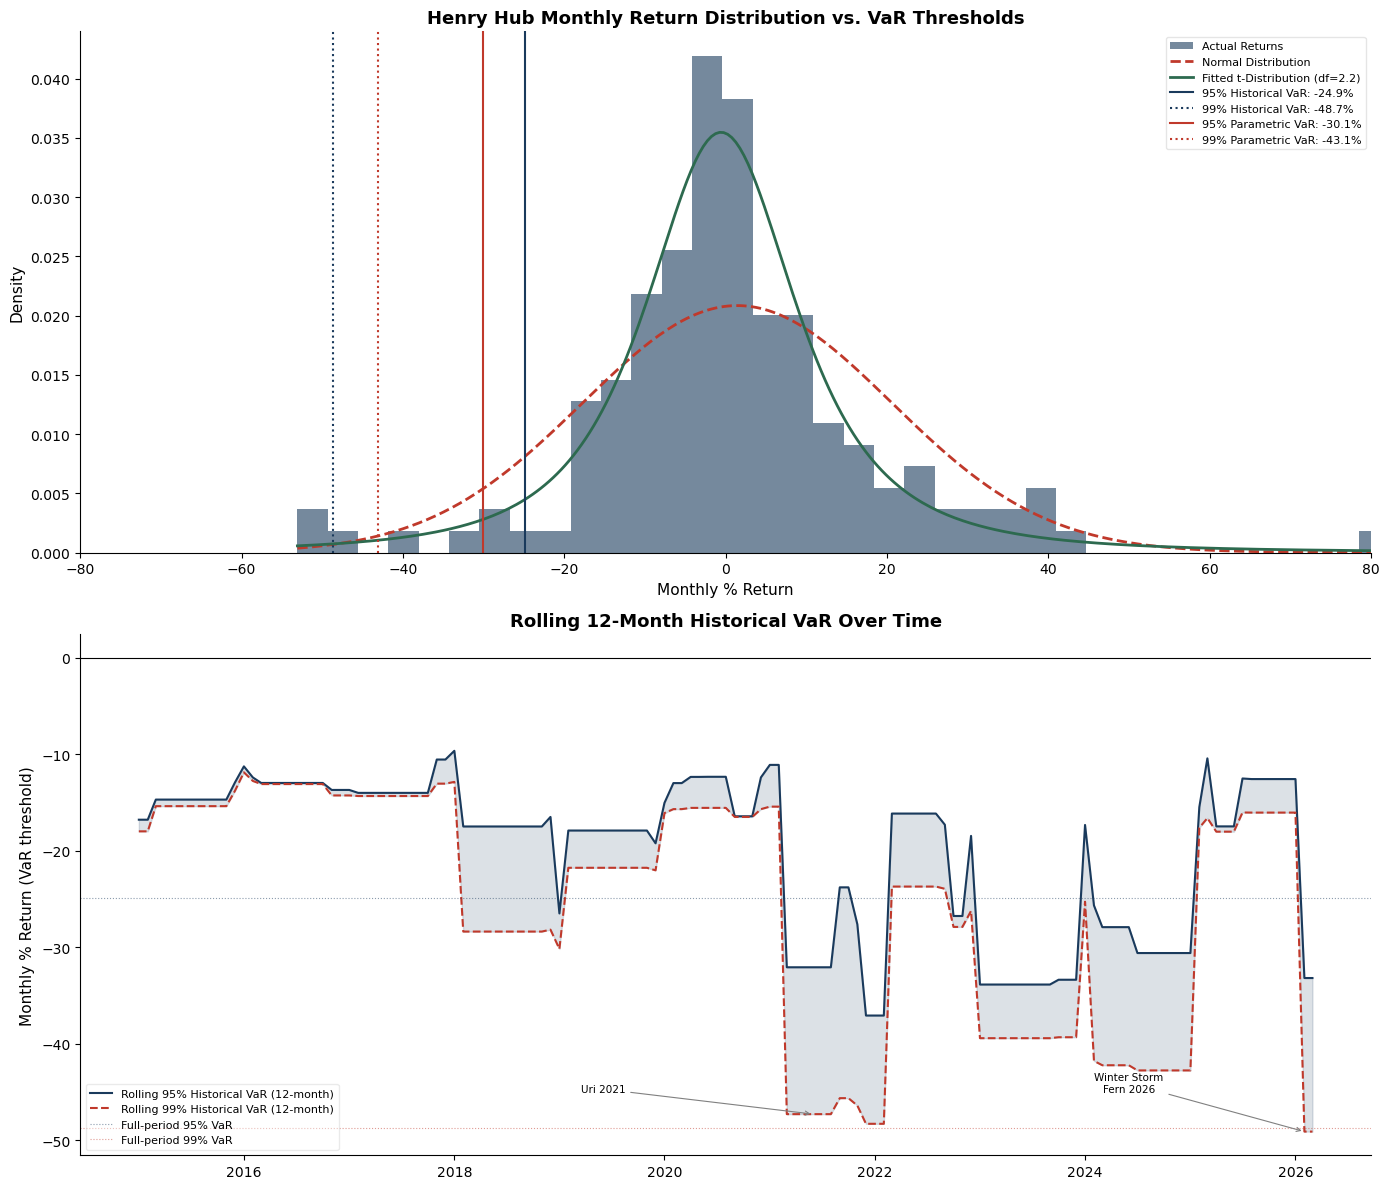

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ── TOP PANEL: Return Distribution with VaR thresholds ──
ax = axes[0]

# Plot histogram of actual returns
ax.hist(returns, bins=40, color="#1a3a5c", alpha=0.6, 
        density=True, label="Actual Returns")

# Overlay normal distribution
x = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = stats.norm.pdf(x, mu, sigma)
ax.plot(x, normal_pdf, color="#c0392b", linewidth=2, 
        linestyle="--", label="Normal Distribution")

# Overlay fitted t-distribution
t_pdf = stats.t.pdf(x, df=df_t, loc=loc_t, scale=scale_t)
ax.plot(x, t_pdf, color="#2d6a4f", linewidth=2,
        label=f"Fitted t-Distribution (df={df_t:.1f})")

# Mark VaR thresholds
var_95_hist = np.percentile(returns, 5)
var_99_hist = np.percentile(returns, 1)
var_95_param = mu + stats.norm.ppf(0.05) * sigma
var_99_param = mu + stats.norm.ppf(0.01) * sigma
var_95_t = np.percentile(
    stats.t.rvs(df=df_t, loc=loc_t, scale=scale_t, 
                size=100_000, random_state=42), 5)
var_99_t = np.percentile(
    stats.t.rvs(df=df_t, loc=loc_t, scale=scale_t,
                size=100_000, random_state=42), 1)

ax.axvline(var_95_hist, color="#1a3a5c", linewidth=1.5,
           linestyle="-", label=f"95% Historical VaR: {var_95_hist:.1f}%")
ax.axvline(var_99_hist, color="#1a3a5c", linewidth=1.5,
           linestyle=":", label=f"99% Historical VaR: {var_99_hist:.1f}%")
ax.axvline(var_95_param, color="#c0392b", linewidth=1.5,
           linestyle="-", label=f"95% Parametric VaR: {var_95_param:.1f}%")
ax.axvline(var_99_param, color="#c0392b", linewidth=1.5,
           linestyle=":", label=f"99% Parametric VaR: {var_99_param:.1f}%")

ax.set_title("Henry Hub Monthly Return Distribution vs. VaR Thresholds",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly % Return", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(fontsize=8, framealpha=0.5, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-80, 80)

# ── BOTTOM PANEL: Rolling 12-month VaR ───────────────────
ax2 = axes[1]

window = 12
rolling_var_95 = returns.rolling(window).apply(
    lambda x: np.percentile(x, 5))
rolling_var_99 = returns.rolling(window).apply(
    lambda x: np.percentile(x, 1))

ax2.plot(rolling_var_95.index, rolling_var_95,
         color="#1a3a5c", linewidth=1.5,
         label="Rolling 95% Historical VaR (12-month)")
ax2.plot(rolling_var_99.index, rolling_var_99,
         color="#c0392b", linewidth=1.5, linestyle="--",
         label="Rolling 99% Historical VaR (12-month)")
ax2.fill_between(rolling_var_99.index, rolling_var_99, 
                 rolling_var_95, alpha=0.15, color="#1a3a5c")
ax2.axhline(var_95_hist, color="#1a3a5c", linewidth=0.8,
            linestyle=":", alpha=0.5, label="Full-period 95% VaR")
ax2.axhline(var_99_hist, color="#c0392b", linewidth=0.8,
            linestyle=":", alpha=0.5, label="Full-period 99% VaR")
ax2.axhline(0, color="black", linewidth=0.8)

# Annotate key risk periods
ax2.annotate("Polar Vortex\n2014",
             xy=(pd.Timestamp("2014-06-01"),
                 rolling_var_99.loc["2014-06-01"]),
             xytext=(pd.Timestamp("2016-01-01"), -35),
             fontsize=7.5, ha="center",
             arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax2.annotate("Uri 2021",
             xy=(pd.Timestamp("2021-06-01"),
                 rolling_var_99.loc["2021-06-01"]),
             xytext=(pd.Timestamp("2019-06-01"), -45),
             fontsize=7.5, ha="center",
             arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax2.annotate("Winter Storm\nFern 2026",
             xy=(pd.Timestamp("2026-02-01"),
                 rolling_var_99.loc["2026-02-01"]),
             xytext=(pd.Timestamp("2024-06-01"), -45),
             fontsize=7.5, ha="center",
             arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax2.set_title("Rolling 12-Month Historical VaR Over Time",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Monthly % Return (VaR threshold)", fontsize=11)
ax2.set_xlabel("")
ax2.legend(fontsize=8, framealpha=0.4, loc="lower left")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("var_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
print("=" * 65)
print("HENRY HUB NATURAL GAS — VaR SUMMARY")
print("Monthly Price Returns | Sample: 2014-2026 | N=145 months")
print("=" * 65)
print(f"\nReturn Distribution Characteristics:")
print(f"  Mean monthly return:    {returns.mean():>8.3f}%")
print(f"  Volatility (std dev):   {returns.std():>8.3f}%")
print(f"  Skewness:               {returns.skew():>8.3f}")
print(f"  Kurtosis:               {returns.kurtosis():>8.3f}  (Normal = 0)")
print(f"  Min observed return:    {returns.min():>8.3f}%")
print(f"  Max observed return:    {returns.max():>8.3f}%")

print(f"\n{'Method':<25} {'95% VaR':>10} {'99% VaR':>10}  {'Notes'}")
print("-" * 65)

var_95_hist = np.percentile(returns, 5)
var_99_hist = np.percentile(returns, 1)
var_95_norm = mu + stats.norm.ppf(0.05) * sigma
var_99_norm = mu + stats.norm.ppf(0.01) * sigma
var_95_t = np.percentile(stats.t.rvs(
    df=df_t, loc=loc_t, scale=scale_t, 
    size=100_000, random_state=42), 5)
var_99_t = np.percentile(stats.t.rvs(
    df=df_t, loc=loc_t, scale=scale_t,
    size=100_000, random_state=42), 1)

print(f"{'Historical':<25} {var_95_hist:>9.2f}% {var_99_hist:>9.2f}%"
      f"  Empirical, no assumptions")
print(f"{'Parametric (Normal)':<25} {var_95_norm:>9.2f}% {var_99_norm:>9.2f}%"
      f"  Underestimates tail risk")
print(f"{'Monte Carlo (Normal)':<25} {var_95_norm:>9.2f}% {var_99_norm:>9.2f}%"
      f"  Confirms parametric")
print(f"{'Monte Carlo (t-dist)':<25} {var_95_t:>9.2f}% {var_99_t:>9.2f}%"
      f"  Best tail risk estimate")

print(f"\nKey Finding:")
print(f"  Fitted t-distribution df = {df_t:.2f} — near minimum for finite")
print(f"  variance, confirming extreme fat tails in gas returns.")
print(f"  Parametric 99% VaR underestimates tail risk by")
print(f"  {abs(var_99_t - var_99_norm):.1f} percentage points vs t-distribution.")
print(f"\n  The choice of distributional assumption changes estimated")
print(f"  worst-case monthly loss from {var_99_norm:.1f}% to {var_99_t:.1f}% —")
print(f"  a critical difference for position sizing and risk limits.")
print("=" * 65)

HENRY HUB NATURAL GAS — VaR SUMMARY
Monthly Price Returns | Sample: 2014-2026 | N=145 months

Return Distribution Characteristics:
  Mean monthly return:       1.440%
  Volatility (std dev):     19.146%
  Skewness:                  1.167
  Kurtosis:                  6.007  (Normal = 0)
  Min observed return:     -53.076%
  Max observed return:      97.361%

Method                       95% VaR    99% VaR  Notes
-----------------------------------------------------------------
Historical                   -24.88%    -48.71%  Empirical, no assumptions
Parametric (Normal)          -30.05%    -43.10%  Underestimates tail risk
Monte Carlo (Normal)         -30.05%    -43.10%  Confirms parametric
Monte Carlo (t-dist)         -28.38%    -62.86%  Best tail risk estimate

Key Finding:
  Fitted t-distribution df = 2.20 — near minimum for finite
  variance, confirming extreme fat tails in gas returns.
  Parametric 99% VaR underestimates tail risk by
  19.8 percentage points vs t-distribution.

  T

## SARIMA Forecasting Model
**Seasonal AutoRegressive Integrated Moving Average**

Generates probabilistic price forecasts using the historical Henry Hub price series and seasonal patterns.

- **Data:** Monthly Henry Hub spot price, 2010–present
- **Seasonal period:** m=12 (monthly, annual seasonality)

**Approach:**
1. Prepare and visualize the price series
2. Use auto_arima to select optimal (p,d,q)(P,D,Q)[12]
3. Fit the model and examine diagnostics
4. Generate 12-month ahead forecast with confidence intervals
5. Visualize forecast vs. actual

In [31]:
# Uncomment and run once if pmdarima is not installed
# !pip install pmdarima

In [32]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Use monthly HH price from 2010 onward - modern market era
# This captures the shale revolution and LNG export period
sarima_data = combined["HH_price"].dropna()
sarima_data = sarima_data[sarima_data.index >= "2010-01-01"]
sarima_data = sarima_data[sarima_data.index <= pd.Timestamp.today()]

print(f"SARIMA dataset: {len(sarima_data)} monthly observations")
print(f"Period: {sarima_data.index.min().date()} to {sarima_data.index.max().date()}")
print(f"Seasonal cycles: {len(sarima_data)/12:.1f} full years")
print(f"\nBasic statistics:")
print(sarima_data.describe().round(3))

SARIMA dataset: 198 monthly observations
Period: 2010-01-01 to 2026-06-01
Seasonal cycles: 16.5 full years

Basic statistics:
count    198.000
mean       3.374
std        1.264
min        1.493
25%        2.592
50%        2.995
75%        4.039
max        8.806
Name: HH_price, dtype: float64


In [33]:
# Run auto_arima to find optimal SARIMA parameters
# stepwise=True uses a faster search algorithm
# seasonal=True enables the seasonal component
# m=12 sets annual seasonality for monthly data

print("Running auto_arima parameter search...")
print("This may take 1-2 minutes...\n")

auto_model = pm.auto_arima(
    sarima_data,
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion="aic",
    d=None,          # let auto_arima determine differencing
    D=None,          # let auto_arima determine seasonal differencing
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    trace=True,      # print each model tried
    error_action="ignore",
    suppress_warnings=True,
)

print(f"\nBest model: SARIMA{auto_model.order}{auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.3f}")
print(f"\nModel summary:")
print(auto_model.summary())

Running auto_arima parameter search...
This may take 1-2 minutes...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=415.014, Time=1.15 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=657.587, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=408.953, Time=0.35 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=525.898, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1071.375, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=406.981, Time=0.07 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=408.953, Time=0.24 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=409.437, Time=0.70 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=408.627, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=408.597, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=524.088, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=410.562, Time=0.17 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=420.380, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,

In [34]:
# Compare with forced seasonal differencing
model_seasonal = pm.auto_arima(
    sarima_data,
    seasonal=True,
    m=12,
    stepwise=False,
    D=1,               # force seasonal differencing
    max_p=2,
    max_q=2,
    max_P=2,
    max_Q=2,
    information_criterion="aic",
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
)

print(f"Forced seasonal model: SARIMA{model_seasonal.order}"
      f"{model_seasonal.seasonal_order}")
print(f"AIC: {model_seasonal.aic():.3f}")
print(f"vs best auto model AIC: {auto_model.aic():.3f}")
print(f"\nDifference: {model_seasonal.aic() - auto_model.aic():.3f}")
print("(Positive = forced seasonal model is worse)")

Forced seasonal model: SARIMA(2, 0, 1)(2, 1, 0, 12)
AIC: 442.562
vs best auto model AIC: 406.981

Difference: 35.582
(Positive = forced seasonal model is worse)


In [35]:
# Generate 12-month ahead forecast
n_forecast = 12

forecast, conf_int = auto_model.predict(
    n_periods=n_forecast,
    return_conf_int=True,
    alpha=0.05  # 95% confidence interval
)

# Build forecast date index
last_date = sarima_data.index[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=n_forecast,
    freq="MS"
)

forecast_series = pd.Series(forecast, index=forecast_dates)
conf_lower = pd.Series(conf_int[:, 0], index=forecast_dates)
conf_upper = pd.Series(conf_int[:, 1], index=forecast_dates)

print("12-Month Henry Hub Price Forecast:")
print(f"{'Date':<15} {'Forecast':>10} {'Lower 95%':>10} {'Upper 95%':>10}")
print("-" * 48)
for date, fc, lo, hi in zip(forecast_dates, forecast, 
                             conf_int[:,0], conf_int[:,1]):
    print(f"{str(date.date()):<15} {fc:>9.3f}  {lo:>9.3f}  {hi:>9.3f}")

12-Month Henry Hub Price Forecast:
Date              Forecast  Lower 95%  Upper 95%
------------------------------------------------
2026-07-01          3.152      1.851      4.454
2026-08-01          3.194      1.483      4.905
2026-09-01          3.229      1.272      5.186
2026-10-01          3.259      1.141      5.377
2026-11-01          3.285      1.057      5.513
2026-12-01          3.307      1.002      5.612
2027-01-01          3.326      0.966      5.685
2027-02-01          3.342      0.943      5.740
2027-03-01          3.355      0.928      5.782
2027-04-01          3.367      0.920      5.814
2027-05-01          3.377      0.915      5.839
2027-06-01          3.385      0.913      5.858


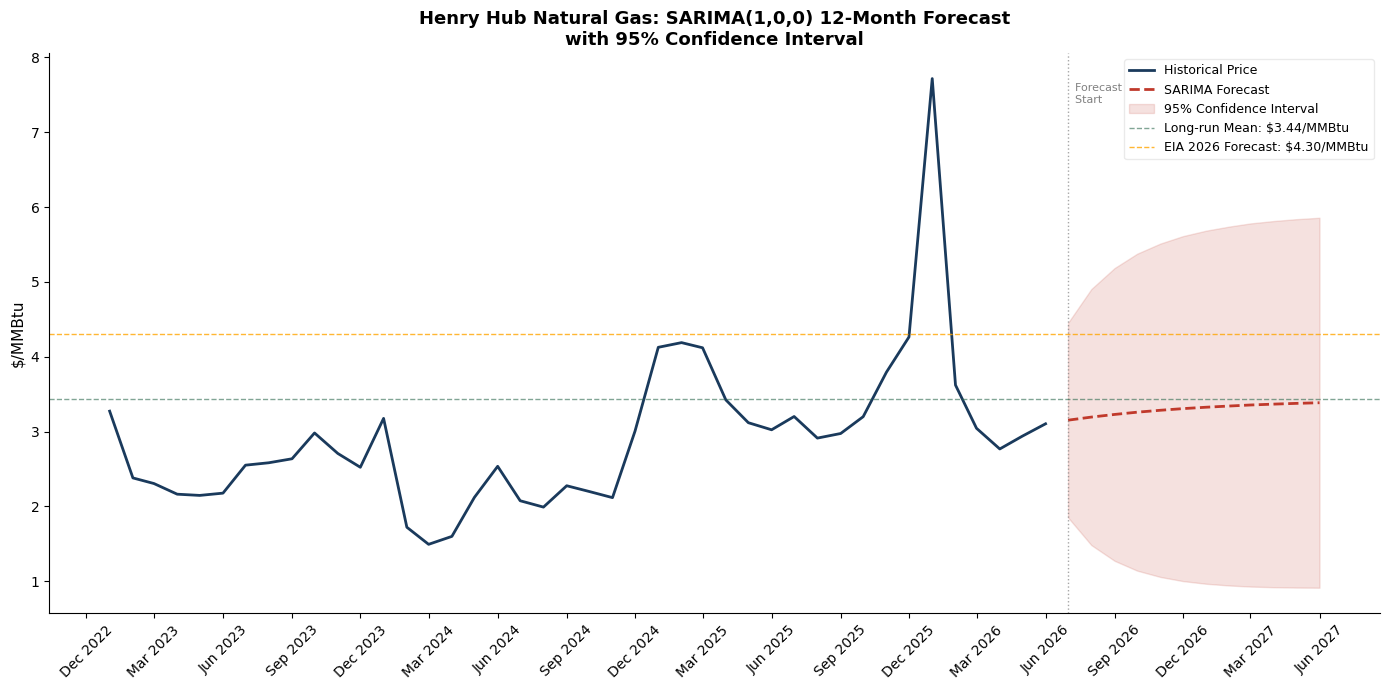

In [36]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot historical prices - last 3 years for context
history_window = sarima_data[sarima_data.index >= "2023-01-01"]
ax.plot(history_window.index, history_window.values,
        color="#1a3a5c", linewidth=2, label="Historical Price")

# Plot forecast
ax.plot(forecast_series.index, forecast_series.values,
        color="#c0392b", linewidth=2, linestyle="--",
        label="SARIMA Forecast")

# Confidence interval
ax.fill_between(forecast_dates,
                conf_lower, conf_upper,
                color="#c0392b", alpha=0.15,
                label="95% Confidence Interval")

# Mark the forecast start
ax.axvline(forecast_dates[0],
           color="gray", linewidth=1, linestyle=":",
           alpha=0.7)
ax.text(forecast_dates[0], ax.get_ylim()[1] * 0.95,
        "  Forecast\n  Start",
        fontsize=8, color="gray", va="top")

# Mark long-run mean
long_run_mean = auto_model.params()[0] / (1 - auto_model.params()[1])
ax.axhline(long_run_mean, color="#2d6a4f", linewidth=1,
           linestyle="--", alpha=0.6,
           label=f"Long-run Mean: ${long_run_mean:.2f}/MMBtu")

# Add EIA 2026 forecast for comparison
ax.axhline(4.30, color="orange", linewidth=1,
           linestyle="--", alpha=0.8,
           label="EIA 2026 Forecast: $4.30/MMBtu")

ax.set_title("Henry Hub Natural Gas: SARIMA(1,0,0) 12-Month Forecast\n"
             "with 95% Confidence Interval",
             fontsize=13, fontweight="bold")
ax.set_ylabel("$/MMBtu", fontsize=11)
ax.set_xlabel("")
ax.legend(fontsize=9, framealpha=0.4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## GARCH(1,1) Volatility Model

Models time-varying volatility in Henry Hub daily log returns using a Generalized Autoregressive Conditional Heteroskedasticity (GARCH) framework.

- **Data:** Daily Henry Hub spot price, 1996–2026
- **Returns:** Log returns scaled to percent
- **Distribution:** Standardized Student's t (fat tails)

**Key Results:**
- α(1) = 0.207, β(1) = 0.777 — persistence sum of ~0.98, confirming volatility is highly persistent in natural gas markets
- ν = 4.29 — low degrees of freedom confirming extreme fat tails
- Conditional volatility spikes visible around 2002, 2008–09, 2021–22 (Ukraine/energy crisis)

**GARCH-Based VaR** uses current conditional volatility rather than a fixed historical window, providing a dynamic risk estimate that responds to current market conditions.

In [37]:
#!pip install arch
#Uncomment and run once is arch not already installed

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                    Henry Hub   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -20531.3
Distribution:      Standardized Student's t   AIC:                           41072.6
Method:                  Maximum Likelihood   BIC:                           41107.1
                                              No. Observations:                 7399
Date:                      Sun, Jun 28 2026   Df Residuals:                     7398
Time:                              10:55:12   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------

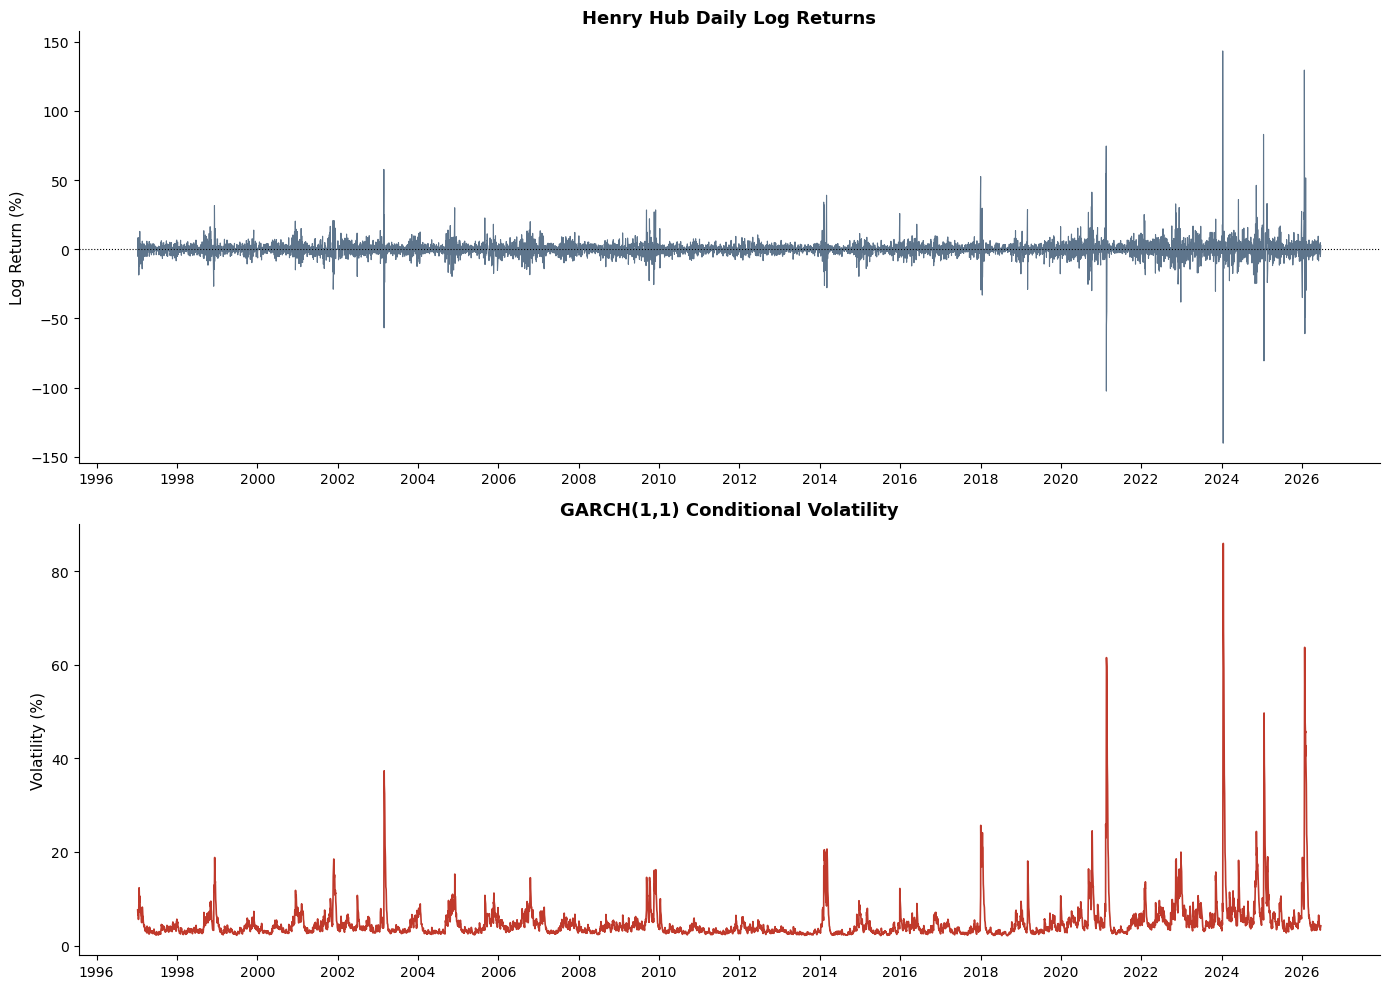


--- GARCH-Based VaR (Daily Log Returns) ---
  95% VaR: -8.7730%
  99% VaR: -15.1284%


In [38]:
from arch import arch_model

# --- Log returns from daily Henry Hub price ---
log_returns = np.log(df["Henry Hub"] / df["Henry Hub"].shift(1)).dropna()
log_returns = log_returns * 100  # Scale to percent for numerical stability

# --- Fit GARCH(1,1) ---
garch_model = arch_model(log_returns, vol="Garch", p=1, q=1, dist="t")
garch_result = garch_model.fit(disp="off")
print(garch_result.summary())

# --- Conditional volatility ---
cond_vol = garch_result.conditional_volatility

# --- Plot 1: Log Returns & Conditional Volatility ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(log_returns.index, log_returns.values,
             color="#1a3a5c", linewidth=0.8, alpha=0.7, label="Log Returns")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_title("Henry Hub Daily Log Returns", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Log Return (%)", fontsize=11)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(cond_vol.index, cond_vol.values,
             color="#c0392b", linewidth=1.2, label="Conditional Volatility")
axes[1].set_title("GARCH(1,1) Conditional Volatility", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Volatility (%)", fontsize=11)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("garch_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

# --- GARCH-Based VaR ---
confidence_levels = [0.95, 0.99]
latest_vol = cond_vol.iloc[-1]
mean_return = log_returns.mean()

from scipy.stats import t as t_dist
nu = garch_result.params.get("nu", 10)  # Degrees of freedom from t-distribution

garch_var = {}
for cl in confidence_levels:
    alpha = 1 - cl
    t_quantile = t_dist.ppf(alpha, df=nu)
    var = mean_return + latest_vol * t_quantile
    garch_var[cl] = var

print("\n--- GARCH-Based VaR (Daily Log Returns) ---")
for cl, var in garch_var.items():
    print(f"  {int(cl*100)}% VaR: {var:.4f}%")

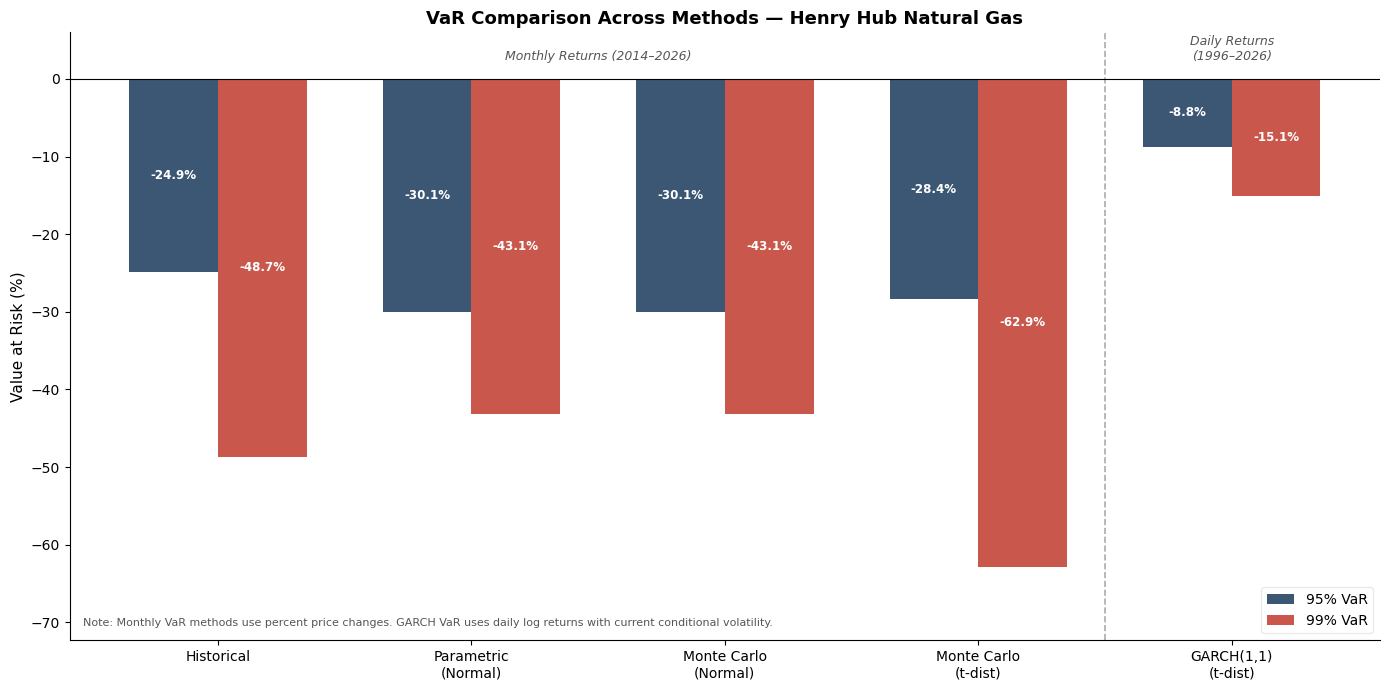

In [39]:
# --- VaR Comparison: All Methods ---
methods = [
    "Historical",
    "Parametric\n(Normal)",
    "Monte Carlo\n(Normal)",
    "Monte Carlo\n(t-dist)",
    "GARCH(1,1)\n(t-dist)"
]

var_95 = [var_95_hist, var_95_norm, var_95_norm, var_95_t, garch_var[0.95]]
var_99 = [var_99_hist, var_99_norm, var_99_norm, var_99_t, garch_var[0.99]]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width/2, var_95, width,
               label="95% VaR", color="#1a3a5c", alpha=0.85)
bars2 = ax.bar(x + width/2, var_99, width,
               label="99% VaR", color="#c0392b", alpha=0.85)

# Value labels on bars
for bar in bars1:
    height = bar.get_height()
    if abs(height) > 2:
        ax.text(bar.get_x() + bar.get_width()/2, height / 2,
                f"{height:.1f}%", ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold")

for bar in bars2:
    height = bar.get_height()
    if abs(height) > 2:
        ax.text(bar.get_x() + bar.get_width()/2, height / 2,
                f"{height:.1f}%", ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold")

# Divider line between monthly and GARCH
ax.axvline(x=3.5, color="#888888", linewidth=1.2, linestyle="--", alpha=0.7)

# Frequency group labels
ax.text(1.5, 2.5, "Monthly Returns (2014–2026)",
        ha="center", fontsize=9, color="#555555", style="italic")
ax.text(4.0, 2.5, "Daily Returns\n(1996–2026)",
        ha="center", fontsize=9, color="#555555", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel("Value at Risk (%)", fontsize=11)
ax.set_ylim(bottom=min(var_99) * 1.15, top=6)
ax.set_title("VaR Comparison Across Methods — Henry Hub Natural Gas",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.01, 0.02,
        "Note: Monthly VaR methods use percent price changes. GARCH VaR uses daily log returns with current conditional volatility.",
        transform=ax.transAxes, fontsize=8, color="#555555", va="bottom")

plt.tight_layout()
plt.savefig("var_comparison.png", dpi=150, bbox_inches="tight")
plt.show()